In [18]:
from typing import List
import drawsvg as dw
import json
import pandas as pd

In [5]:
with open (r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\provinces.json') as file:
    province = json.load(file)

In [6]:
bcd = province['Bacolod'].strip()

In [7]:
d = dw.Drawing(200,100,origin='center')

In [8]:
bcd = bcd.split(" ")

In [9]:
bcd

['M',
 '97',
 '93.4',
 'L',
 '98.5',
 '94.3',
 'L',
 '97.9',
 '94.7',
 'L',
 '97.6',
 '95',
 'L',
 '97.1',
 '95',
 'L',
 '96.7',
 '94.6',
 'Z']

In [10]:
for i, loc in enumerate(bcd):
    try:
        float(loc)
        print(f"{loc} is number")
    except:
        if loc.isalpha():
            print(loc)

M
97 is number
93.4 is number
L
98.5 is number
94.3 is number
L
97.9 is number
94.7 is number
L
97.6 is number
95 is number
L
97.1 is number
95 is number
L
96.7 is number
94.6 is number
Z


Point:
- the numbers
- the action (M, V, H)

Shape:
- fill color
- list of points
- list of actions in order

Map:
- List of Shapes

In [203]:
class Point:
    def __init__(self, p:List[float], movement:str=None):
        if isinstance(p,list):
            if len(p) == 2:
                self.p1 = float(p[0])
                self.p2 = float(p[1])
            elif len(p) == 1:
                self.p1 = float(p[0])
        else:
            self.p1 = float(p)
        

        self.movement=movement

    def __str__(self):
        cls = self.__class__.__name__
        try:
            return f"{cls}(p1={self.p1}, p2={self.p2}, movement={self.movement})"
        except:
            return f"{cls}(p1={self.p1}, movement={self.movement})"
        
    def __repr__(self):
        cls = self.__class__.__name__
        try:
            return f"{cls}(p1={self.p1}, p2={self.p2}, movement={self.movement})"
        except:
            return f"{cls}(p1={self.p1}, movement={self.movement})"

    def create_line(self, path):
        if self.movement == 'M':
            path.M(self.p1,self.p2)
        elif self.movement == 'L':
            path.L(self.p1,self.p2)
        elif self.movement == 'V':
            path.V(self.p1)
        elif self.movement == 'H':
            path.H(self.p1)

In [204]:
class Shape:
    def __init__(self, points:Point=None, path=None,stroke='black', fill='none'):
        self.points = [points] if not isinstance(points,list) else points
        self.path = path if path is not None else dw.Path(stroke=stroke)
        self.stroke = stroke
        self.fill = fill
        self.group = dw.Group(fill=fill)

    def create_shape(self):
        for point in self.points:
            point.create_line(self.path)
        self.group.append(self.path)

    def __str__(self):
        return "\n".join(str(point) for point in self.points)
    
    def __repr__(self):
        cls = self.__class__.__name__
        return f"{cls}(points=[{self.points[0]}...], path={self.path} stroke={self.stroke}, fill={self.fill})"


In [205]:
class Map:
    def __init__(self, shapes:Shape=None, map_name='map',width=300, height=300):
        self.shapes = [shapes] if not isinstance(shapes,list) else shapes
        self.map = dw.Drawing(width=width, height=height)
        self.map_name = map_name

    def create_map(self):
        for shape in self.shapes:
            self.map.append(shape.create_shape())

    def save_map(self, file_name:str=None, file_path=None ):
        self.map
        if file_name is None:
            if '.svg' in self.map_name:
                file_name = self.map_name
            else:
                file_name = self.map_name + '.svg'

        if file_path is not None:
            save_path = r'/'.join([file_path, file_name])
            self.map.save_svg(save_path)
        else:
            self.map.save_svg(file_name)
        


In [206]:
def process_points(data):
    current_movement = None
    current_points = []
    points = []

    for item in data:
        if item.isalpha():  # Check if the item is a letter
            if current_movement is not None:
                points.append(Point(current_points,current_movement))

            current_movement = item
            current_points = []
        else:  # The item is a number
            current_points.append(item)

    if current_movement is not None:
        if current_movement != 'Z':
            points.append(Point(current_points,current_points))

    return points

In [207]:
# split the list into groups where the start is M and the end is Z
# then create a method to process it, in which one group is one Shape
# the list of Shapes will then be part of Map
# then call Map method to create the image

In [208]:
def process_instructions(data: List[str]):
    result = []
    temp_list = []
    for item in data:
        temp_list.append(item)
        if item == 'Z':
            result.append(temp_list)
            temp_list = []
    return result

In [209]:
def process_shapes(data:List[list]):
    shapes = []
    for shape in data:
        shapes.append(Shape(process_points(shape)))

    return shapes

In [210]:
def create_map(data):
    instructions = process_instructions(data)
    shapes = process_shapes(instructions)
    map_shape = Map(shapes=shapes)
    map_shape.create_map()
    map_shape.save_map()

In [213]:
create_map(bcd)

In [191]:
d = dw.Drawing(200, 100, origin='center')
d.append(dw.Lines(-80, 45,
                     70, 49,
                     95, -49,
                    -90, -40,
                    close=False,
            fill='#eeee00',
            stroke='black'))


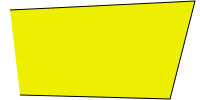

In [192]:
d